In [1]:
!pip install transformers datasets evaluate accelerate torch

In [2]:
!pip install transformers datasets evaluate accelerate torch

In [3]:
%pip install --upgrade ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [30]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [32]:
import random

random.seed(42)
np.random.seed(42)

In [61]:
import os

os.makedirs("plots", exist_ok=True)

In [31]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.13.0+cpu
CUDA available: False


In [33]:
%pip install --upgrade huggingface_hub

Note: you may need to restart the kernel to use updated packages.


In [62]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

In [63]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [43]:
dataset.keys()

dict_keys(['train', 'test', 'unsupervised'])

In [64]:
print(dataset["train"][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [65]:
dataset["train"].features

{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}

In [66]:
print(dataset["train"][0]["text"])
print(dataset["train"][0]["label"])


I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, eve

In [67]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

In [68]:
train_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [69]:
train_df.shape

(25000, 2)

In [70]:
test_df.shape

(25000, 2)

In [71]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 32.0 MB


In [72]:
test_df.isnull().sum()

text     0
label    0
dtype: int64

In [73]:
train_df.duplicated().sum()

np.int64(96)

In [74]:
test_df.duplicated().sum()

np.int64(199)

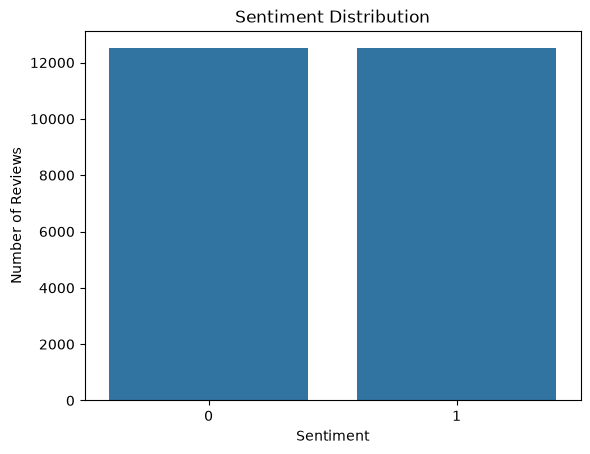

In [75]:
sns.countplot(data=train_df, x="label")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.savefig("plots/Sentiment Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [77]:
train_df["sentiment"] = train_df["label"].map({
    0: "Negative",
    1: "Positive"
})

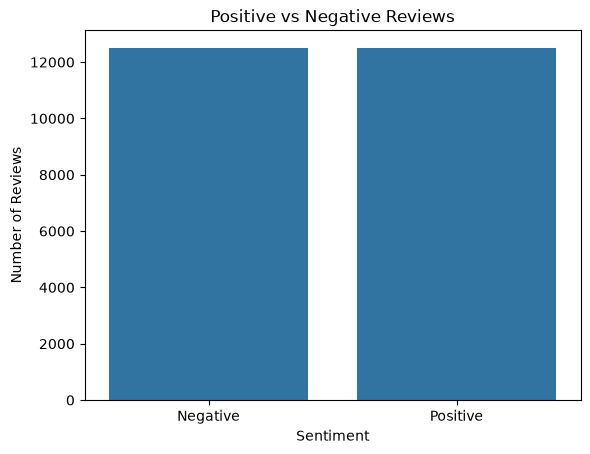

In [79]:
sns.countplot(data=train_df, x="sentiment")

plt.title("Positive vs Negative Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.savefig("plots/Positive vs Negative Reviews.png", dpi=300, bbox_inches="tight")

plt.show()

In [81]:
train_df["review_length"] = train_df["text"].str.len()

In [82]:
train_df["review_length"].describe()

count    25000.00000
mean      1325.06964
std       1003.13367
min         52.00000
25%        702.00000
50%        979.00000
75%       1614.00000
max      13704.00000
Name: review_length, dtype: float64

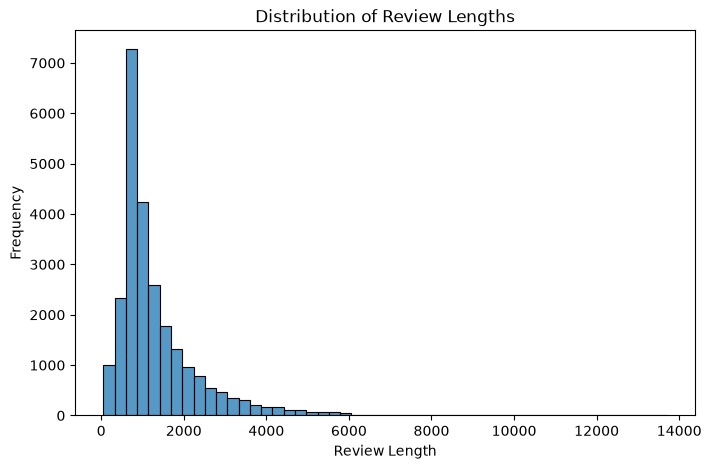

In [84]:
plt.figure(figsize=(8,5))

sns.histplot(
    train_df["review_length"],
    bins=50
)

plt.title("Distribution of Review Lengths")
plt.xlabel("Review Length")
plt.ylabel("Frequency")

plt.savefig("plots/Review_Length_Distribution.png",bbox_inches="tight")

plt.show()

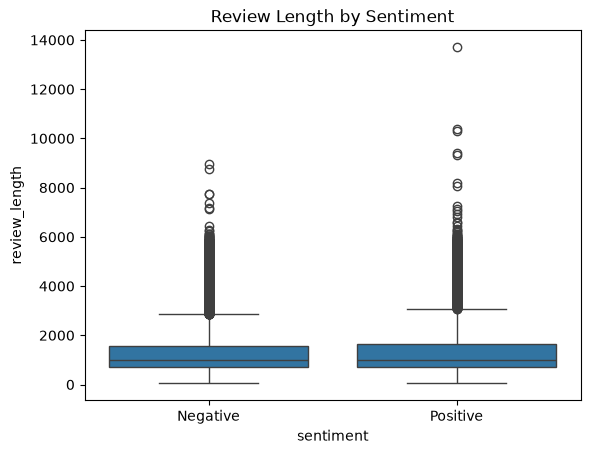

In [85]:
sns.boxplot(
    data=train_df,
    x="sentiment",
    y="review_length"
)

plt.title("Review Length by Sentiment")
plt.savefig("plots/Review_Length_Vs_Sentiment.png",bbox_inches="tight")
plt.show()

In [86]:
train_df[train_df["label"] == 1]["text"].head()

12500    Zentropa has much in common with The Third Man...
12501    Zentropa is the most original movie I've seen ...
12502    Lars Von Trier is never backward in trying out...
12503    *Contains spoilers due to me having to describ...
12504    That was the first thing that sprang to mind a...
Name: text, dtype: str

In [87]:
train_df[train_df["label"] == 0]["text"].head()

0    I rented I AM CURIOUS-YELLOW from my video sto...
1    "I Am Curious: Yellow" is a risible and preten...
2    If only to avoid making this type of film in t...
3    This film was probably inspired by Godard's Ma...
4    Oh, brother...after hearing about this ridicul...
Name: text, dtype: str

In [36]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

In [37]:
train_dataset = Dataset.from_pandas(
    train_df[["text", "label"]]
)

val_dataset = Dataset.from_pandas(
    val_df[["text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]]
)

In [38]:
print(train_dataset)

Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 20000
})


In [39]:
import numpy as np
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [40]:
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

In [41]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [28]:
print(model)

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(

In [29]:
print("tokenized_train" in globals())
print("tokenized_val" in globals())

False
False


In [19]:
print("small_val:", "small_val" in globals())
print("y_small_pred_baseline:", "y_small_pred_baseline" in globals())
print("y_val_distilbert:", "y_val_distilbert" in globals())
print("positive_probability:", "positive_probability" in globals())

small_val: False
y_small_pred_baseline: False
y_val_distilbert: False
positive_probability: False


In [18]:
print(tokenized_train[0])

NameError: name 'tokenized_train' is not defined

In [ ]:
print("train_df:", "train_df" in globals())
print("val_df:", "val_df" in globals())
print("test_df:", "test_df" in globals())
print("dataset:", "dataset" in globals())
print("model:", "model" in globals())
print("tokenizer:", "tokenizer" in globals())

In [ ]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

In [ ]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

In [ ]:
print(train_df.shape)
print(test_df.shape)

In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

In [ ]:
print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["text", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["text", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]],
    preserve_index=False
)

In [ ]:
print(train_dataset)
print(val_dataset)

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

In [ ]:
MAX_LENGTH = 256

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

In [ ]:
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)

In [ ]:
print("tokenized_train:", "tokenized_train" in globals())
print("tokenized_val:", "tokenized_val" in globals())
print("tokenized_test:", "tokenized_test" in globals())

In [ ]:
print(tokenized_train[0])

In [ ]:
print("model:", "model" in globals())

In [ ]:
print("model:", "model" in globals())
print("tokenizer:", "tokenizer" in globals())
print("tokenized_train:", "tokenized_train" in globals())
print("tokenized_val:", "tokenized_val" in globals())

In [ ]:
import evaluate
import numpy as np

accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")


def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(
        predictions=predictions,
        references=labels
    )["accuracy"]

    precision = precision_metric.compute(
        predictions=predictions,
        references=labels,
        average="binary"
    )["precision"]

    recall = recall_metric.compute(
        predictions=predictions,
        references=labels,
        average="binary"
    )["recall"]

    f1 = f1_metric.compute(
        predictions=predictions,
        references=labels,
        average="binary"
    )["f1"]

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
small_train = tokenized_train.select(range(2000))
small_val = tokenized_val.select(range(500))

print("Training examples:", len(small_train))
print("Validation examples:", len(small_val))

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./models/distilbert_dev",

    eval_strategy="epoch",
    save_strategy="no",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=1,

    weight_decay=0.01,

    report_to="none"
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_val,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

In [ ]:
dev_result = {
    "Model": "DistilBERT",
    "Experiment": "Development",
    "Training Samples": 2000,
    "Validation Samples": 500,
    "Epochs": 1,
    "Learning Rate": 2e-5,
    "Batch Size": 8,
    "Max Length": 256,
    "Validation Loss": 0.322357,
    "Accuracy": 0.876000,
    "Precision": 0.880309,
    "Recall": 0.880309,
    "F1": 0.880309,
    "Training Time (sec)": 1962.2795
}

dev_result

In [ ]:
import pandas as pd

experiment_df = pd.DataFrame([dev_result])

experiment_df.to_csv(
    "models/distilbert_development_results.csv",
    index=False
)

experiment_df

In [ ]:
predictions = trainer.predict(small_val)

In [ ]:
print(predictions.metrics)

In [ ]:
import numpy as np

y_val_distilbert = np.argmax(
    predictions.predictions,
    axis=1
)

y_val_distilbert[:20]

In [ ]:
y_val_actual = np.array(
    small_val["label"]
)

In [ ]:
print(y_val_actual[:20])
print(y_val_distilbert[:20])

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_distilbert = confusion_matrix(
    y_val_actual,
    y_val_distilbert
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_distilbert,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("DistilBERT Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "plots/distilbert_confusion_matrix.png",
    dpi=300
)

plt.show()

In [ ]:
from scipy.special import softmax

probabilities = softmax(
    predictions.predictions,
    axis=1
)

positive_probability = probabilities[:, 1]

In [ ]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_val_actual,
    positive_probability
)

print("DistilBERT ROC-AUC:", roc_auc)

In [ ]:
trainer.save_model(
    "models/distilbert_development"
)

tokenizer.save_pretrained(
    "models/distilbert_development"
)

In [ ]:
import os

print(os.listdir("models/distilbert_development"))

In [ ]:
predictions = trainer.predict(small_val)

In [ ]:
import numpy as np

y_val_distilbert = np.argmax(
    predictions.predictions,
    axis=1
)

y_val_actual = np.array(
    small_val["label"]
)

In [ ]:
from scipy.special import softmax
from sklearn.metrics import roc_auc_score

probabilities = softmax(
    predictions.predictions,
    axis=1
)

positive_probability = probabilities[:, 1]

roc_auc = roc_auc_score(
    y_val_actual,
    positive_probability
)

print("DistilBERT ROC-AUC:", roc_auc)

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_distilbert = confusion_matrix(
    y_val_actual,
    y_val_distilbert
)

print(cm_distilbert)

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_distilbert,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("DistilBERT Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "plots/distilbert_confusion_matrix.png",
    dpi=300
)

plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

distilbert_accuracy = accuracy_score(
    y_val_actual,
    y_val_distilbert
)

distilbert_precision = precision_score(
    y_val_actual,
    y_val_distilbert
)

distilbert_recall = recall_score(
    y_val_actual,
    y_val_distilbert
)

distilbert_f1 = f1_score(
    y_val_actual,
    y_val_distilbert
)

print("DistilBERT Validation Results")
print("-----------------------------")
print("Accuracy :", distilbert_accuracy)
print("Precision:", distilbert_precision)
print("Recall   :", distilbert_recall)
print("F1 Score :", distilbert_f1)
print("ROC-AUC  :", roc_auc)

In [ ]:
import time

start_time = time.time()

predictions = trainer.predict(small_val)

end_time = time.time()

total_time = end_time - start_time

latency_per_review = (
    total_time / len(small_val)
)

print("Total inference time:", total_time, "seconds")
print("Inference latency per review:", latency_per_review, "seconds")

In [ ]:
print("DistilBERT ROC-AUC:", roc_auc)

In [ ]:
print("Total inference time:", total_time, "seconds")
print("Inference latency per review:", latency_per_review, "seconds")

In [ ]:
error_df = pd.DataFrame({
    "text": small_val["text"],
    "actual": y_val_actual,
    "predicted": y_val_distilbert,
    "positive_probability": positive_probability
})

error_df["actual_sentiment"] = error_df["actual"].map({
    0: "Negative",
    1: "Positive"
})

error_df["predicted_sentiment"] = error_df["predicted"].map({
    0: "Negative",
    1: "Positive"
})

In [ ]:
errors = error_df[
    error_df["actual"] != error_df["predicted"]
].copy()

print("Total validation reviews:", len(error_df))
print("Incorrect predictions:", len(errors))
print(
    "Error rate:",
    len(errors) / len(error_df)
)

In [ ]:
pd.set_option("display.max_colwidth", 300)

errors[
    [
        "text",
        "actual_sentiment",
        "predicted_sentiment",
        "positive_probability"
    ]
].head(10)

In [ ]:
errors["uncertainty"] = abs(
    errors["positive_probability"] - 0.5
)

In [ ]:
uncertain_errors = errors.sort_values(
    "uncertainty"
).head(10)

uncertain_errors[
    [
        "text",
        "actual_sentiment",
        "predicted_sentiment",
        "positive_probability"
    ]
]

In [ ]:
errors[
    [
        "text",
        "actual_sentiment",
        "predicted_sentiment",
        "positive_probability"
    ]
].to_csv(
    "models/distilbert_error_cases.csv",
    index=False
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [ ]:
import joblib

tfidf = joblib.load("models/tfidf_vectorizer.pkl")
lr_model = joblib.load("models/logistic_regression.pkl")

In [ ]:
# Transform validation reviews using the saved TF-IDF vectorizer
X_val = tfidf.transform(val_df["text"])

# Get the actual validation labels
y_val = val_df["label"]

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

In [ ]:
y_val_pred_baseline = lr_model.predict(X_val)

y_val_prob_baseline = lr_model.predict_proba(X_val)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

baseline_accuracy = accuracy_score(
    y_val,
    y_val_pred_baseline
)

baseline_precision = precision_score(
    y_val,
    y_val_pred_baseline
)

baseline_recall = recall_score(
    y_val,
    y_val_pred_baseline
)

baseline_f1 = f1_score(
    y_val,
    y_val_pred_baseline
)

baseline_roc_auc = roc_auc_score(
    y_val,
    y_val_prob_baseline
)

In [ ]:
print("TF-IDF + Logistic Regression")
print("----------------------------")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")
print(f"ROC-AUC  : {baseline_roc_auc:.4f}")

In [ ]:
small_val_text = small_val["text"]
small_val_labels = np.array(small_val["label"])

print("Number of reviews:", len(small_val_text))

In [ ]:
X_small_val_baseline = tfidf.transform(
    small_val_text
)

In [ ]:
print(X_small_val_baseline.shape)

In [ ]:
y_small_pred_baseline = lr_model.predict(
    X_small_val_baseline
)

y_small_prob_baseline = lr_model.predict_proba(
    X_small_val_baseline
)[:, 1]

In [ ]:
baseline_small_accuracy = accuracy_score(
    small_val_labels,
    y_small_pred_baseline
)

baseline_small_precision = precision_score(
    small_val_labels,
    y_small_pred_baseline
)

baseline_small_recall = recall_score(
    small_val_labels,
    y_small_pred_baseline
)

baseline_small_f1 = f1_score(
    small_val_labels,
    y_small_pred_baseline
)

baseline_small_roc_auc = roc_auc_score(
    small_val_labels,
    y_small_prob_baseline
)

In [ ]:
print("TF-IDF + Logistic Regression — Same 500 Reviews")
print("-----------------------------------------------")
print(f"Accuracy : {baseline_small_accuracy:.4f}")
print(f"Precision: {baseline_small_precision:.4f}")
print(f"Recall   : {baseline_small_recall:.4f}")
print(f"F1 Score : {baseline_small_f1:.4f}")
print(f"ROC-AUC  : {baseline_small_roc_auc:.4f}")

In [ ]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "TF-IDF + Logistic Regression": [
        baseline_small_accuracy,
        baseline_small_precision,
        baseline_small_recall,
        baseline_small_f1,
        baseline_small_roc_auc
    ],
    "DistilBERT": [
        distilbert_accuracy,
        distilbert_precision,
        distilbert_recall,
        distilbert_f1,
        roc_auc
    ]
})

comparison_df

In [ ]:
from sklearn.metrics import confusion_matrix

cm_baseline = confusion_matrix(
    small_val_labels,
    y_small_pred_baseline
)

print("Baseline Confusion Matrix:")
print(cm_baseline)

In [ ]:
cm_distilbert = confusion_matrix(
    y_val_actual,
    y_val_distilbert
)

print("DistilBERT Confusion Matrix:")
print(cm_distilbert)

The confusion matrices show that TF-IDF + Logistic Regression performed better than DistilBERT on the 500-review validation subset. Logistic Regression correctly classified 451 reviews, with 212 true negatives and 239 true positives, while producing 29 false positives and 20 false negatives. DistilBERT correctly classified 438 reviews, with 210 true negatives and 228 true positives, while producing 31 false positives and 31 false negatives. The larger number of false negatives for DistilBERT helps explain its lower recall of 88.03% compared with 92.28% for Logistic Regression.

In [ ]:
baseline_errors = baseline_error_df[
    baseline_error_df["actual"] != baseline_error_df["predicted"]
].copy()

distilbert_errors = error_df[
    error_df["actual"] != error_df["predicted"]
].copy()

print("Baseline errors:", len(baseline_errors))
print("DistilBERT errors:", len(distilbert_errors))